# Imports

In [1]:
import matplotlib.pyplot as plt
#%matplotlib qt
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import os

from moabb.datasets import BNCI2015_013
import mne
from mne.preprocessing import ICA

from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, validation_curve, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, make_scorer,confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, roc_curve, auc, precision_score, recall_score

# Dataset MOABB

[Dataset link](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2015_013.html)

In [2]:
dataset = BNCI2015_013()

In [3]:
subjects = [1, 2, 3, 4, 5, 6]
data = dataset.get_data(subjects=subjects)

### Dictonaries

In [ ]:
event_dict = {'Target': 0, "NonTarget": 1}
X_dict = {}
y_dict = {}    
results = {
    'within': [],
    'cross': []
}

### Loading and preprocessing

In [ ]:
for subject_id in subjects:
    print(f"Processing subject: {subject_id}")
    X_sub_list = []
    y_sub_list = []
    for session_id in data[subject_id].keys():
        for run_id in data[subject_id][session_id].keys():
            raw_run = data[subject_id][session_id][run_id].copy()
            
            # FIR (Bandpass) for 1-10 Hz
            raw_run.filter(l_freq=1.0, h_freq=10.0, fir_design='firwin', verbose=False)

            # CAR - Common Average Reference
            raw_run.set_eeg_reference(verbose=False)
            
            events, _ = mne.events_from_annotations(raw_run, event_id=event_dict, verbose=False)

            epochs = mne.Epochs(
                raw=raw_run,
                events=events,
                event_id=event_dict,
                tmin=-0.2,
                tmax=0.8,
                baseline=(-0.2, 0),
                decim=4,
                preload=True,
                picks='eeg',
                verbose=False
            )

            X_sub_list.append(epochs.get_data(copy=True))
            y_sub_list.append(epochs.events[:, -1])

    X_dict[subject_id] = np.concatenate(X_sub_list, axis=0)
    y_dict[subject_id] = np.concatenate(y_sub_list, axis=0)

Przetwarzam pacjenta: 1
Przetwarzam pacjenta: 2
Przetwarzam pacjenta: 3
Przetwarzam pacjenta: 4
Przetwarzam pacjenta: 5
Przetwarzam pacjenta: 6


# Pipeline
We will use Xdawn covariances, which calculate extract the noise from the channels (Xdawn) and calulcate the covariances on clean channels.
Then we move our data to Riemannian tangent space in which a Linear SVM can perform classification.

In [ ]:
pipe = Pipeline([
    ('xdawn', XdawnCovariances(nfilter=4, estimator='oas', xdawn_estimator='oas')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', SVC(
        class_weight='balanced',
        kernel='linear',
        C=0.1,
        random_state=42
    ))
])

# Model

### Within subject

In [ ]:
for subject_id in subjects:    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * 0.80)
    
    # Split the data chronologically (NO SHUFFLING)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    

    # Checking if every class is present in the test set
    unique_classes, counts = np.unique(y_test, return_counts=True)
    if 0 not in unique_classes:
        print(f"WARNING: Subject {subject_id} does not have the Target class in the test set!")

    # Train the model on the past (Calibration)
    pipe.fit(X_train, y_train)
    
    # Test the model on the future (Active Steering)
    y_pred = pipe.predict(X_test)
    for ytrue, ypred in zip(y_test, y_pred):
        results['within'].append({
            'subject': subject_id,
            'y_true': ytrue,
            'y_pred': ypred
        })

#### ROC and AUC

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * 0.70)
    
    # Podział chronologiczny
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    
    # Trenowanie
    pipe.fit(X_train, y_train)
    
    # Zamiast twardego .predict(), pobieramy ciągłe wartości zaufania modelu
    y_scores = pipe.decision_function(X_test)
    
    # Wyliczanie FPR, TPR oraz optymalnych progów. 
    # Pamiętamy o pos_label=1 (Klasa BŁĄD)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    # Wizualizacja
    ax = axes[i]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowe zgadywanie')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (Fałszywe Alarmy)')
    ax.set_ylabel('True Positive Rate (Wykryte Błędy)')
    ax.set_title(f'Pacjent S{subject_id:02d}', fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Krzywe ROC dla detekcji sygnału ErrP (Klasa BŁĄD)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Cross-subject

In [ ]:
for test_subject in subjects:
    X_train = np.concatenate([X_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    y_train = np.concatenate([y_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    X_test = X_dict[test_subject]
    
    pipe.fit(X_train, y_train)
    y_pred_cross = pipe.predict(X_test)
    for ytrue, ypred in zip(y_dict[test_subject], y_pred_cross):
        results['cross'].append({
            'subject': test_subject,
            'y_true': ytrue,
            'y_pred': ypred
        })

KeyboardInterrupt: 

### Save to CSV

In [ ]:
pd.DataFrame(results['within']).to_csv("riemann_moabb_within.csv", index=False)
#pd.DataFrame(results['cross']).to_csv("riemann_moabb_cross.csv", index=False)

# Wizki

In [ ]:
df_within = pd.read_csv("riemann_moabb_within.csv")
#df_cross = pd.read_csv("riemann_moabb_cross.csv")
results_table = []

### Metrics function

In [ ]:
def calculate_metrics(df, experiment_name):

    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"{subject}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })

In [ ]:
calculate_metrics(df_within, 'Within-Subject')
#calculate_metrics(df_cross, 'Cross-Subject')
df_results = pd.DataFrame(results_table)

In [ ]:
print("--- RESULTS TABLE ---")
print(df_results.to_string(index=False))

--- TABELA ZBIORCZA WYNIKÓW ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject       1                  77.47            0.882             0.911          0.855
Within-Subject       2                  88.02            0.949             0.965          0.933
Within-Subject       3                  79.70            0.923             0.930          0.917
Within-Subject       4                  88.57            0.972             0.945          1.000
Within-Subject       5                  82.59            0.905             0.932          0.879
Within-Subject       6                  51.92            0.751             0.815          0.696


In [ ]:
pd.DataFrame(df_results.to_csv("riemann_moabb_results.csv", index=False))

""


In [ ]:
def plot_confusion_matrices(df, experiment_name, filename):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()
    
    subjects_list = sorted(df['subject'].unique())
    
    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'ERROR'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(f"Patient {sub_id}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Class')
        ax.set_ylabel('True Class')
    
    plt.suptitle(f"Confusion Matrices - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

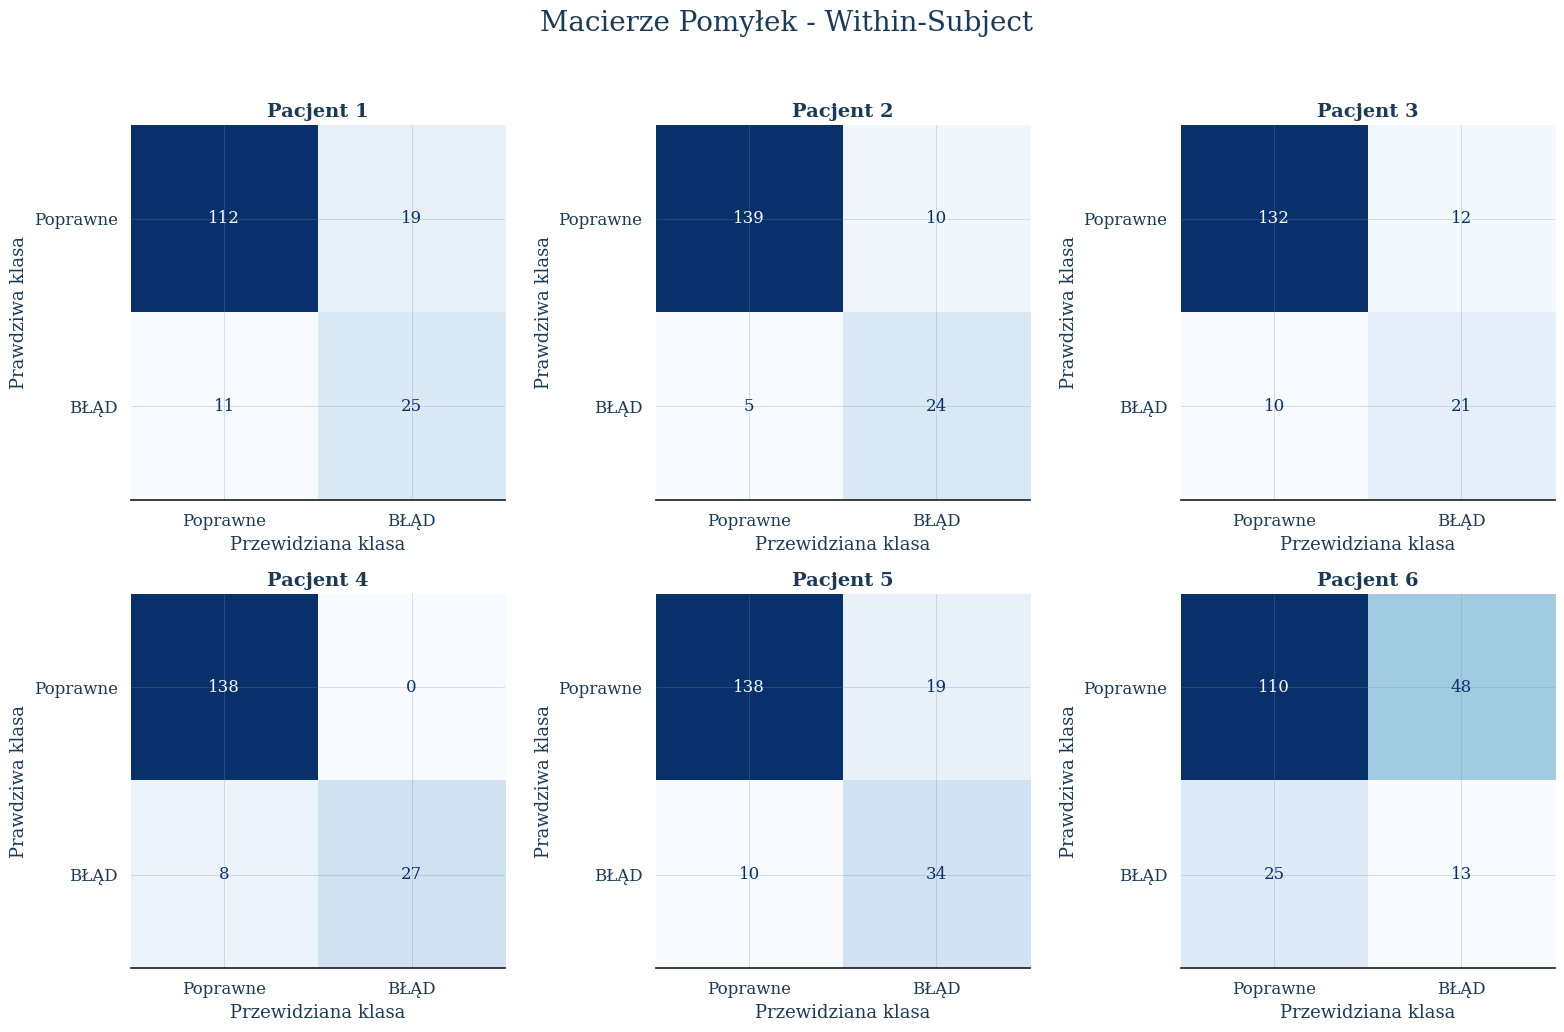

In [ ]:
plot_confusion_matrices(df_within, 'Within-Subject', 'Riemann_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'Riemann_Cross_Subject.png')

In [ ]:
# Create subplots for each metric
df = pd.read_csv("riemann_moabb_results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.savefig("riemann_moabb_results.svg", dpi=300)

# MISC

## Chat

#### Checking how many data we need

In [ ]:
step_size = 50 
learning_curve_results = []

for subject_id in subjects:
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]
    
    total_trials = len(X_sub)
    split_idx = int(total_trials * 0.80)
    
    # 1. Stały zbiór testowy z samej końcówki nagrania (symulacja rzeczywistego działania)
    X_test = X_sub[split_idx:]
    y_test = y_sub[split_idx:]
    
    # 2. Generowanie progów wielkości zbioru treningowego (np. 50, 100, 150... aż do split_idx)
    # Zaczynamy od np. 50, ponieważ Xdawn potrzebuje minimum kilku prób docelowych
    train_sizes = list(range(step_size, split_idx, step_size))
    
    # Upewniamy się, że ostatnim krokiem jest pełny zbiór kalibracyjny (70%)
    if train_sizes[-1] != split_idx:
        train_sizes.append(split_idx)
        
    for n_train in train_sizes:
        # Chronologiczne pobranie pierwszych n_train próbek
        X_train = X_sub[:n_train]
        y_train = y_sub[:n_train]
        
        # Opcjonalne zabezpieczenie: pomiń krok, jeśli w wylosowanych próbach nie ma obu klas
        if len(np.unique(y_train)) < 2:
            continue
            
        # Trenowanie i predykcja
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        # Zapisywanie metryk (Pamiętaj o pos_label=0 dla klasy błędu)
        acc = balanced_accuracy_score(y_test, y_pred) * 100
        f1 = f1_score(y_test, y_pred, pos_label=1)
        
        learning_curve_results.append({
            'Subject': subject_id,
            'Train_Size': n_train,
            'Balanced_Accuracy': acc,
            'F1_Score': f1
        })

df_learning_curve = pd.DataFrame(learning_curve_results)

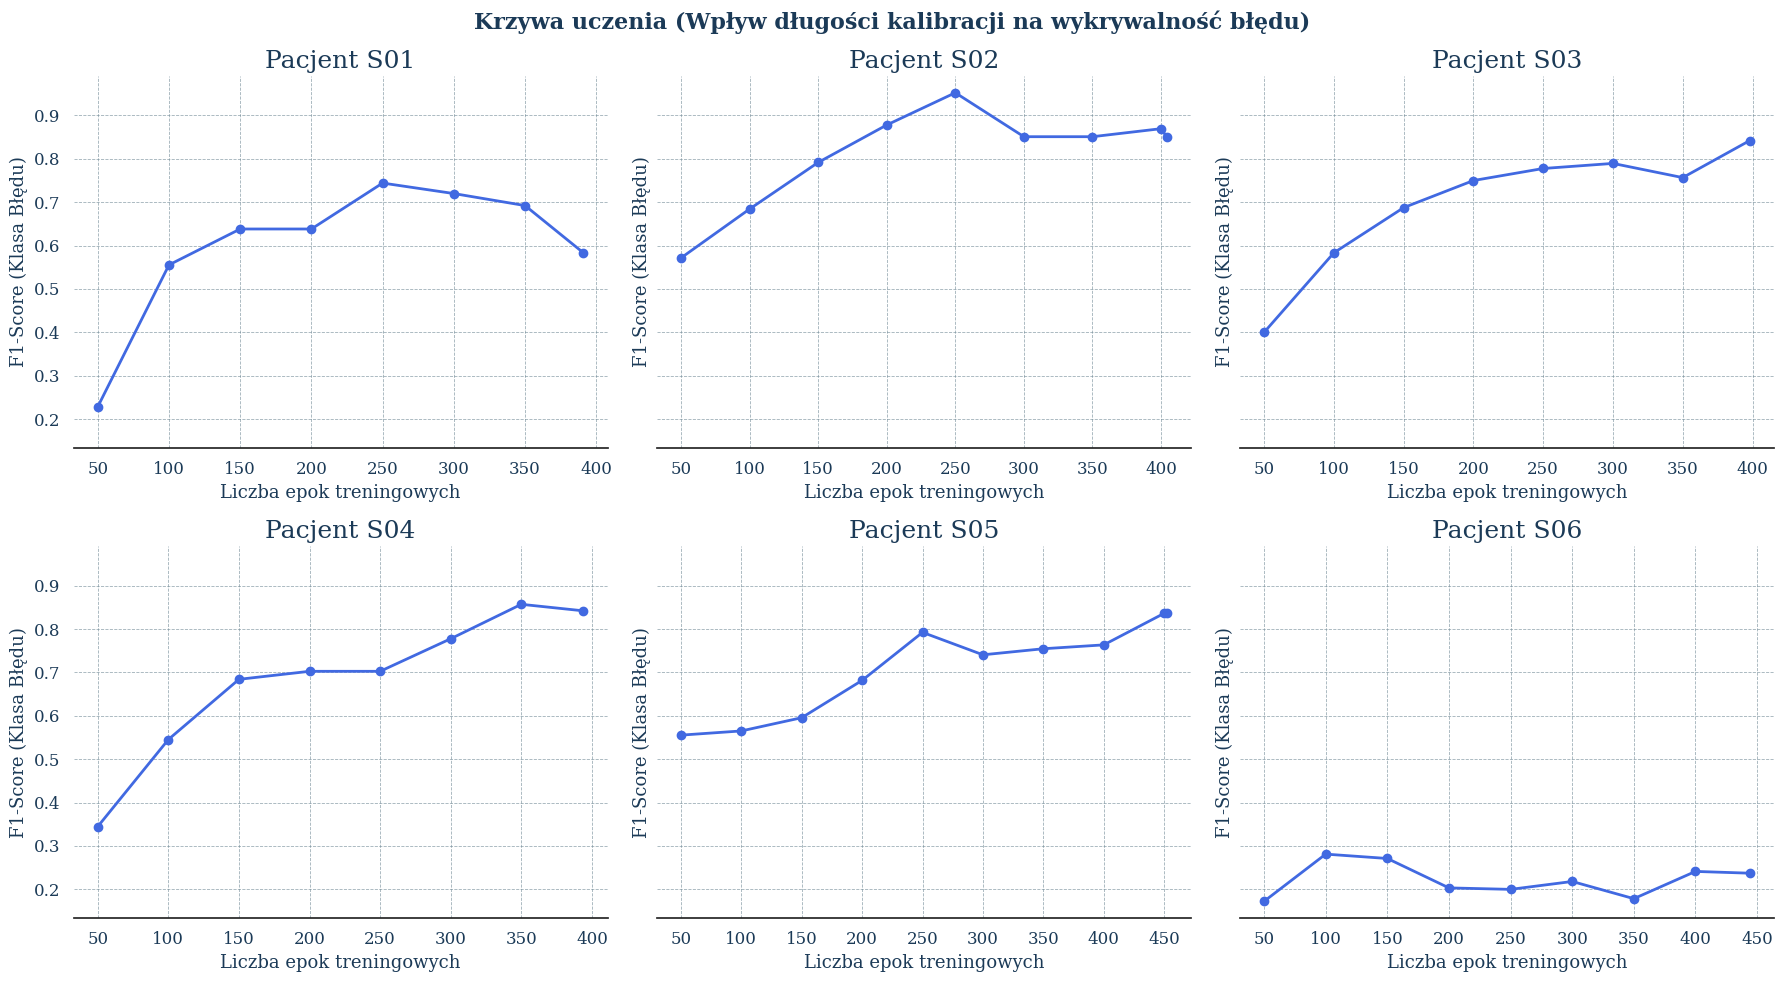

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    df_sub = df_learning_curve[df_learning_curve['Subject'] == subject_id]
    
    ax = axes[i]
    ax.plot(df_sub['Train_Size'], df_sub['F1_Score'], marker='o', color='royalblue', linewidth=2)
    ax.set_title(f'Pacjent S{subject_id:02d}')
    ax.set_xlabel('Liczba epok treningowych')
    ax.set_ylabel('F1-Score (Klasa Błędu)')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Krzywa uczenia (Wpływ długości kalibracji na wykrywalność błędu)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

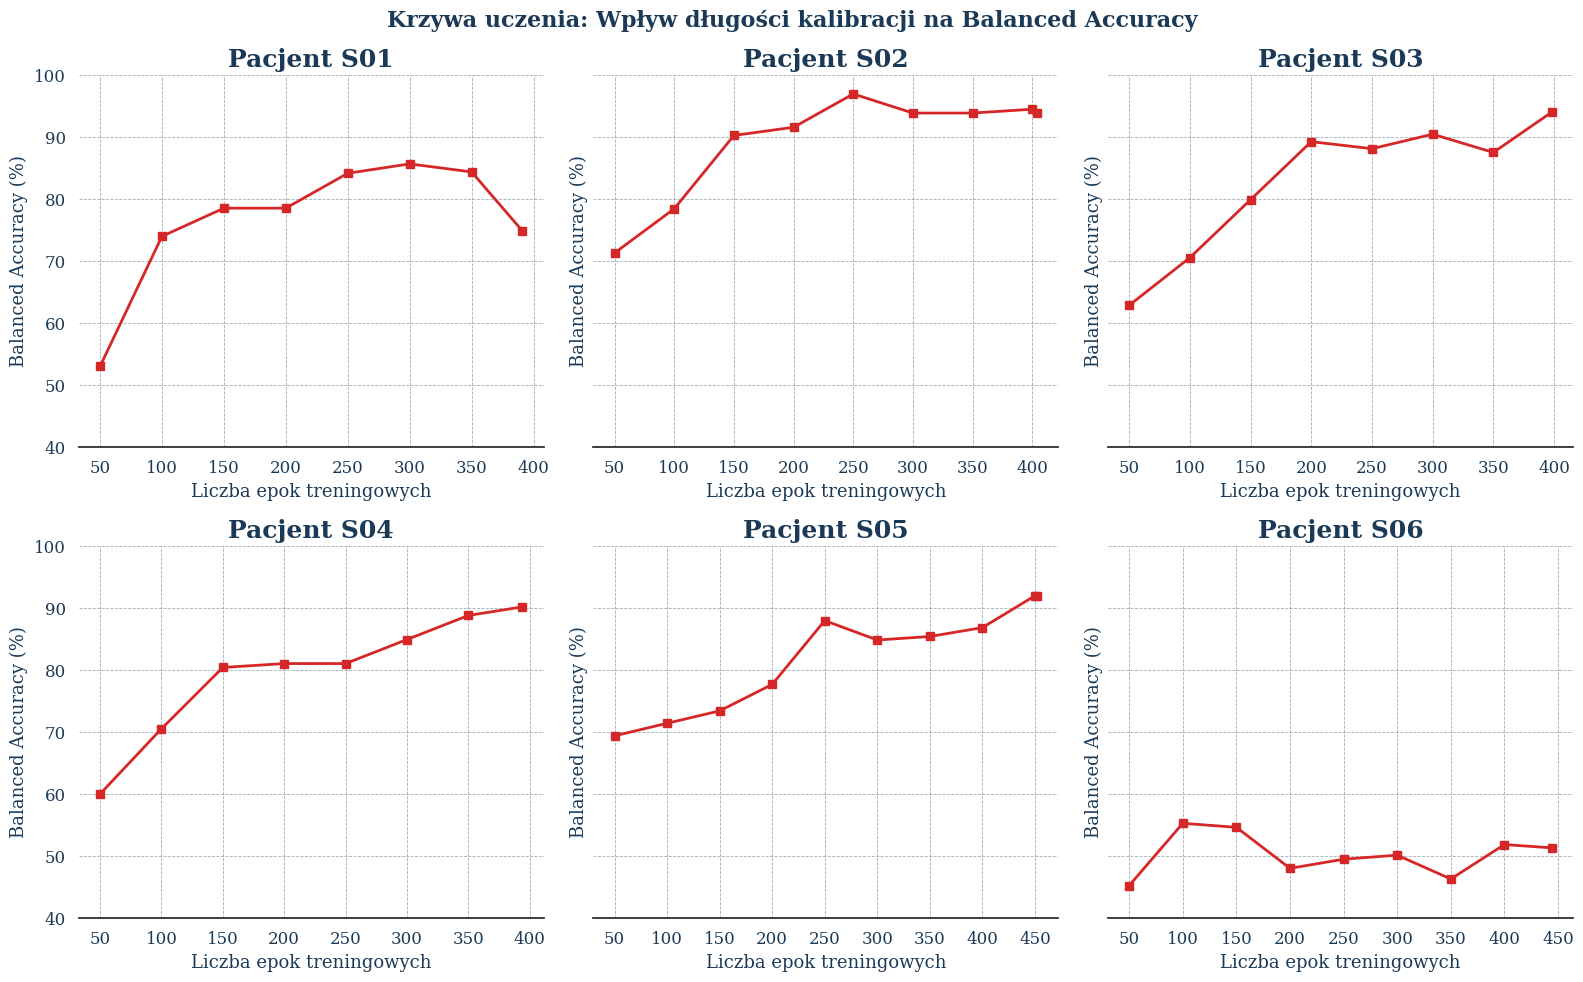

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    df_sub = df_learning_curve[df_learning_curve['Subject'] == subject_id]
    
    ax = axes[i]
    ax.plot(df_sub['Train_Size'], df_sub['Balanced_Accuracy'], marker='s', color='tab:red', linewidth=2)
    
    ax.set_title(f'Pacjent S{subject_id:02d}', fontweight='bold')
    ax.set_xlabel('Liczba epok treningowych')
    ax.set_ylabel('Balanced Accuracy (%)')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Ustawienie sztywnych granic dla osi Y ułatwia wizualne porównanie pacjentów
    ax.set_ylim(40, 100) 

plt.suptitle('Krzywa uczenia: Wpływ długości kalibracji na Balanced Accuracy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Badanie ilościowe

In [ ]:
for subject_id in subjects:
    # Extract the shape of the data array
    total_trials, channels, time_samples = X_dict[subject_id].shape
    
    # Calculate how many trials go into the 70% split
    split_idx = int(total_trials * 0.70)
    test_trials = total_trials - split_idx
    
    print(f"--- Pacjent {subject_id} ---")
    print(f"Całkowita liczba prób (Epochs): {total_trials}")
    print(f"Liczba kanałów (Channels):      {channels}")
    print(f"Próbki czasowe (Time samples):  {time_samples}")
    print(f"  -> Trening (Kalibracja):      {split_idx} prób")
    print(f"  -> Test (Sterowanie):         {test_trials} prób\n")

--- Pacjent 1 ---
Całkowita liczba prób (Epochs): 1044
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      730 prób
  -> Test (Sterowanie):         314 prób

--- Pacjent 2 ---
Całkowita liczba prób (Epochs): 1080
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      756 prób
  -> Test (Sterowanie):         324 prób

--- Pacjent 3 ---
Całkowita liczba prób (Epochs): 1036
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      725 prób
  -> Test (Sterowanie):         311 prób

--- Pacjent 4 ---
Całkowita liczba prób (Epochs): 1052
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      736 prób
  -> Test (Sterowanie):         316 prób

--- Pacjent 5 ---
Całkowita liczba prób (Epochs): 1123
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      786 pr

### GridSearch okien czasowych

In [ ]:
# Zdefiniowanie przestrzeni poszukiwań (krok co 0.1 sekundy)
tmins = np.arange(-0.5, 0.1, 0.1)
tmaxs = np.arange(0.5, 1.1, 0.1)

# -------------------------------------------------------------------
# ETAP 1: Optymalizacja I/O - jednorazowe filtrowanie
# -------------------------------------------------------------------
print("KROK 1: Wstępne filtrowanie i referencja wszystkich nagrań...")
preprocessed_data = {}

for subject_id in subjects:
    preprocessed_data[subject_id] = {}
    for session_id in data[subject_id].keys():
        preprocessed_data[subject_id][session_id] = {}
        for run_id in data[subject_id][session_id].keys():
            # Kopia surowego nagrania
            raw_run = data[subject_id][session_id][run_id].copy()
            
            # Filtrowanie i CAR wykonywane TYLKO RAZ
            raw_run.filter(l_freq=1.0, h_freq=10.0, fir_design='firwin', verbose=False)
            raw_run.set_eeg_reference(verbose=False)
            
            preprocessed_data[subject_id][session_id][run_id] = raw_run

print("Filtrowanie zakończone. Rozpoczynam przeszukiwanie siatki okien czasowych.")
print("-" * 60)

# -------------------------------------------------------------------
# ETAP 2: Grid Search (Pętla po oknach czasowych)
# -------------------------------------------------------------------
results_grid = []

for tmin in tmins:
    for tmax in tmaxs:
        tmin = round(tmin, 1)
        tmax = round(tmax, 1)
        
        # Wykluczenie okien zbyt krótkich dla estymatora Xdawn (min. 0.6 s)
        if tmax - tmin < 0.6:
            continue
            
        # Dynamiczna korekta bazowa - jeśli tmin = 0, baseline musi wynosić None
        baseline = (tmin, 0) if tmin < 0 else None
        
        X_dict_window = {}
        y_dict_window = {}
        
        # Ekstrakcja epok dla bieżącej kombinacji
        for subject_id in subjects:
            X_sub_list = []
            y_sub_list = []
            for session_id in preprocessed_data[subject_id].keys():
                for run_id in preprocessed_data[subject_id][session_id].keys():
                    raw_run = preprocessed_data[subject_id][session_id][run_id]
                    events, _ = mne.events_from_annotations(raw_run, event_id=event_dict, verbose=False)
                    
                    epochs = mne.Epochs(
                        raw=raw_run,
                        events=events,
                        event_id=event_dict,
                        tmin=tmin,
                        tmax=tmax,
                        baseline=baseline,
                        decim=4, 
                        preload=True,
                        picks='eeg',
                        verbose=False
                    )
                    X_sub_list.append(epochs.get_data(copy=True))
                    y_sub_list.append(epochs.events[:, -1])
                    
            X_dict_window[subject_id] = np.concatenate(X_sub_list, axis=0)
            y_dict_window[subject_id] = np.concatenate(y_sub_list, axis=0)
            
        # Trenowanie i ocena
        f1_scores = []
        bacc_scores = []
        
        for subject_id in subjects:
            X_sub = X_dict_window[subject_id]
            y_sub = y_dict_window[subject_id]
            
            split_idx = int(len(X_sub) * 0.70)
            X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
            X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
            
            # Zabezpieczenie przed brakiem obu klas w zbiorach (istotne dla słabych pacjentów)
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue
                
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            
            # Pos_label = 1 (klasa błędu ErrP)
            f1 = f1_score(y_test, y_pred, pos_label=1)
            bacc = balanced_accuracy_score(y_test, y_pred)
            
            f1_scores.append(f1)
            bacc_scores.append(bacc)
            
        # Agregacja wyników dla danej kombinacji (średnia po wszystkich prawidłowych pacjentach)
        avg_f1 = np.mean(f1_scores) if f1_scores else 0
        avg_bacc = np.mean(bacc_scores) if bacc_scores else 0
        
        results_grid.append({
            'tmin': tmin,
            'tmax': tmax,
            'Długość [s]': round(tmax - tmin, 1),
            'Średni_F1': avg_f1,
            'Średni_BAcc': avg_bacc
        })
        
        print(f"Zbadano okno: [{tmin:>4}, {tmax:>4}] -> F1: {avg_f1:.4f} | BAcc: {avg_bacc:.4f}")

# -------------------------------------------------------------------
# ETAP 3: Podsumowanie wyników
# -------------------------------------------------------------------
df_grid = pd.DataFrame(results_grid)
# Sortowanie malejąco według F1-Score, który jest krytyczny dla rzadkiej klasy błędu
df_grid_sorted = df_grid.sort_values(by='Średni_F1', ascending=False).reset_index(drop=True)

print("\n--- TOP 5 NAJLEPSZYCH OKIEN CZASOWYCH ---")
print(df_grid_sorted.head(5).to_string(index=False))

KROK 1: Wstępne filtrowanie i referencja wszystkich nagrań...
Filtrowanie zakończone. Rozpoczynam przeszukiwanie siatki okien czasowych.
------------------------------------------------------------
Zbadano okno: [-0.5,  0.5] -> F1: 0.6098 | BAcc: 0.7730
Zbadano okno: [-0.5,  0.6] -> F1: 0.6040 | BAcc: 0.7701
Zbadano okno: [-0.5,  0.7] -> F1: 0.6356 | BAcc: 0.7884
Zbadano okno: [-0.5,  0.8] -> F1: 0.6414 | BAcc: 0.7937
Zbadano okno: [-0.5,  0.9] -> F1: 0.6471 | BAcc: 0.7968
Zbadano okno: [-0.5,  1.0] -> F1: 0.6480 | BAcc: 0.7961
Zbadano okno: [-0.5,  1.1] -> F1: 0.6484 | BAcc: 0.7943
Zbadano okno: [-0.4,  0.5] -> F1: 0.5950 | BAcc: 0.7634
Zbadano okno: [-0.4,  0.6] -> F1: 0.6021 | BAcc: 0.7670
Zbadano okno: [-0.4,  0.7] -> F1: 0.6349 | BAcc: 0.7905
Zbadano okno: [-0.4,  0.8] -> F1: 0.6375 | BAcc: 0.7913
Zbadano okno: [-0.4,  0.9] -> F1: 0.6431 | BAcc: 0.7967
Zbadano okno: [-0.4,  1.0] -> F1: 0.6486 | BAcc: 0.7967
Zbadano okno: [-0.4,  1.1] -> F1: 0.6422 | BAcc: 0.7898
Zbadano okno: [-0.

In [ ]:
# 1. Zapis do pliku CSV
nazwa_pliku_csv = 'grid_search_okno_czasowe.csv'
df_grid_sorted.to_csv(nazwa_pliku_csv, index=False)
print(f"\nWyniki zapisano pomyślnie do pliku: {nazwa_pliku_csv}")


Wyniki zapisano pomyślnie do pliku: grid_search_okno_czasowe.csv


In [ ]:
df = pd.read_csv('grid_search_okno_czasowe.csv')

# ---- Pivot table ----
pivot = df.pivot_table(index="tmax", columns="tmin", values="Średni_F1")

# ---- Plot heatmap with matplotlib ----
plt.figure(figsize=(10, 7))
plt.imshow(pivot, cmap="viridis", aspect="auto", origin="lower")

# Add colorbar
plt.colorbar(label="F1 Score")

# Tick labels
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)

plt.xlabel("tmin")
plt.ylabel("tmax")
plt.title("Heatmap of avg. F1 Score")

# Annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.3f}", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv('grid_search_okno_czasowe.csv')

# ---- Pivot table ----
pivot = df.pivot_table(index="tmax", columns="tmin", values="Średni_BAcc")

# ---- Plot heatmap with matplotlib ----
plt.figure(figsize=(10, 7))
plt.imshow(pivot, cmap="viridis", aspect="auto", origin="lower")

# Add colorbar
plt.colorbar(label="Balanced Accuracy (%)")

# Tick labels
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)

plt.xlabel("tmin")
plt.ylabel("tmax")
plt.title("Heatmap of Balanced Accuracy (matplotlib only)")

# Annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.3f}", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()


### GridSearch parametrów

In [ ]:
# 1. Definicja potoku (bez twardego kodowania nfilter i C, zostaną one nadpisane)
pipe = Pipeline([
    ('xdawn', XdawnCovariances(estimator='oas', xdawn_estimator='oas')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', SVC(class_weight='balanced', kernel='linear', random_state=42))
])

# 2. Przestrzeń poszukiwań (Grid)
param_grid = {
    # Liczba filtrów przestrzennych. 
    # 2-3 to standard, 4-6 pozwala wyciągnąć więcej detali, ale ryzykuje przeuczeniem.
    'xdawn__nfilter': [2, 3, 4, 5, 6, 7],
    
    # Parametr regularyzacji SVM. 
    # Mniejsze wartości (0.01, 0.1) silniej ignorują szum. Większe (0.5, 1.0) tworzą twardszą granicę.
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# 3. Konfiguracja GridSearchCV
# Używamy StratifiedKFold z 3 podziałami, aby zachować proporcje klas (błąd vs poprawne) w każdym foldzie.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gsearch = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',           # Optymalizujemy stricte pod kątem F1-Score
    cv=cv_strategy,
    n_jobs=-1,              # Użycie wszystkich rdzeni procesora (znaczne przyspieszenie)
    verbose=1               # Wyświetla postęp w konsoli
)

# Słownik do przechowywania najlepszych modeli dla każdego pacjenta
best_models = {}
grid_results_list = []

print("Rozpoczynam Grid Search dla optymalnego okna czasowego...\n")

for subject_id in subjects: # Zakładamy, że X_dict i y_dict mają już dane z okna np. [-0.2, 1.0]
    print(f"--- Optymalizacja pacjenta: S{subject_id:02d} ---")
    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]
    
    # Chronologiczny podział na zbiór kalibracyjny (treningowy) i testowy (aktywna jazda)
    split_idx = int(len(X_sub) * 0.70)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    
    # Weryfikacja, czy zbiór treningowy posiada obie klasy
    if len(np.unique(y_train)) < 2:
        print(f"OSTRZEŻENIE: Brak wystarczającej liczby klas w zbiorze treningowym dla S{subject_id:02d}. Pomijam.")
        continue

    # Uruchomienie przeszukiwania siatki TYLKO na zbiorze treningowym
    gsearch.fit(X_train, y_train)
    
    best_pipe = gsearch.best_estimator_
    best_models[subject_id] = best_pipe
    
    print(f"Najlepsze parametry: {gsearch.best_params_}")
    print(f"Najlepszy F1-Score (Cross-Validation): {gsearch.best_score_:.3f}")
    
    # 4. Ostateczna ewaluacja na niewidzianym zbiorze testowym
    y_pred = best_pipe.predict(X_test)
    
    print("\nRaport na ukrytym zbiorze testowym (Przyszłość):")
    print(classification_report(y_test, y_pred, target_names=['Poprawne (0)', 'BŁĄD (1)']))
    print("=" * 60 + "\n")
    
    grid_results_list.append({
        'Pacjent': f"S{subject_id:02d}",
        'Najlepszy nfilter': gsearch.best_params_['xdawn__nfilter'],
        'Najlepsze C': gsearch.best_params_['clf__C'],
        'F1_CV (Trening)': round(gsearch.best_score_, 3)
    })

# Zapisanie ostatecznych hiperparametrów do tabeli
df_params = pd.DataFrame(grid_results_list)
print("Zestawienie optymalnych hiperparametrów dla każdego z pacjentów:")
print(df_params.to_string(index=False))
nazwa_pliku_csv = 'grid_search_params.csv'
df_params.to_csv(nazwa_pliku_csv, index=False)
print(f"\nWyniki zapisano pomyślnie do pliku: {nazwa_pliku_csv}")

Rozpoczynam Grid Search dla optymalnego okna czasowego...

--- Optymalizacja pacjenta: S01 ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najlepsze parametry: {'clf__C': 0.01, 'xdawn__nfilter': 6}
Najlepszy F1-Score (Cross-Validation): 0.795

Raport na ukrytym zbiorze testowym (Przyszłość):
              precision    recall  f1-score   support

Poprawne (0)       0.94      0.92      0.93       238
    BŁĄD (1)       0.77      0.80      0.79        76

    accuracy                           0.89       314
   macro avg       0.85      0.86      0.86       314
weighted avg       0.90      0.89      0.90       314


--- Optymalizacja pacjenta: S02 ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najlepsze parametry: {'clf__C': 0.01, 'xdawn__nfilter': 5}
Najlepszy F1-Score (Cross-Validation): 0.856

Raport na ukrytym zbiorze testowym (Przyszłość):
              precision    recall  f1-score   support

Poprawne (0)       0.95      0.97      0.96       252
  